In [2]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from devmap.utils import save_plot
from devmap.config import set_theme, discrete_cmap
import matplotlib.colors as mcolors
import re

In [5]:
adata = sc.read_h5ad("../data/qiu24_late_integrated_scvi.h5ad")

In [7]:
n_to_subsample = 500_000
if adata.n_obs > n_to_subsample:
    print(f"subsampling from {adata.n_obs} to {n_to_subsample} cells")
    adata = adata[np.random.choice(adata.n_obs, n_to_subsample, replace=False)]

sc.pp.neighbors(adata, use_rep='X_scvi')

Subsampling from 3823378 to 500000 cells for faster plotting


In [8]:
sc.tl.umap(adata, random_state=0)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

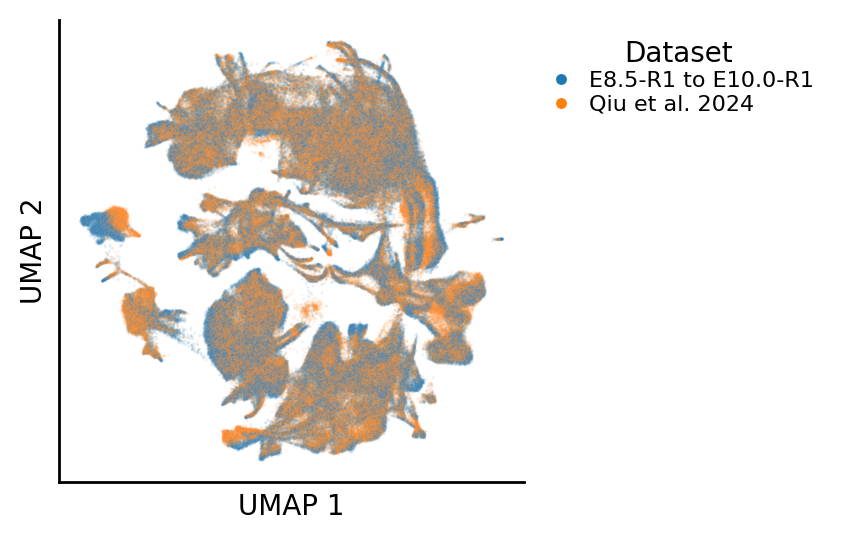

In [18]:
set_theme()

fig = plt.figure(figsize=(3,3), dpi=200)

name_mapping = {
    'qiu2024' :  'Qiu et al. 2024',
    'devmap' : 'E8.5-R1 to E10.0-R1'
}

sns.scatterplot(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    hue=[name_mapping.get(x, x) for x in adata.obs["dataset"]],
    s=1,alpha=0.1,
    palette='tab10')


# set alpha of legend markers to 1
handles, labels = plt.gca().get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
plt.legend(title="Dataset", loc='upper left', bbox_to_anchor=(1, 1),
           markerscale=4, fontsize=8)
plt.xticks([])
plt.yticks([])
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')

save_plot("integration/late_integration_umap.svg", fig)

In [29]:
adata = sc.read_h5ad("../data/qiu2022_integrated_scvi.h5ad")

adata_qiu = adata[adata.obs["dataset"] == "qiu2022"]
adata_qiu = adata_qiu[~adata_qiu.obs['day'].isin(['E6.5', 'E6.75'])]
adata_devmap = adata[adata.obs["dataset"] == "devmap"]

# subsample devmap to match qiu
n_to_subsample = adata_qiu.n_obs
if adata_devmap.n_obs > n_to_subsample:
    print(f"subsampling devmap from {adata_devmap.n_obs} to {n_to_subsample} cells")
    adata_devmap = adata_devmap[np.random.choice(adata_devmap.n_obs, n_to_subsample, replace=False)]

subsampling devmap from 115984 to 71868 cells


In [30]:
adata = adata_qiu.concatenate(adata_devmap)

sc.pp.neighbors(adata, use_rep='X_scvi')

sc.tl.umap(adata, random_state=0)

/tmp/ipykernel_127450/1657862741.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_qiu.concatenate(adata_devmap)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

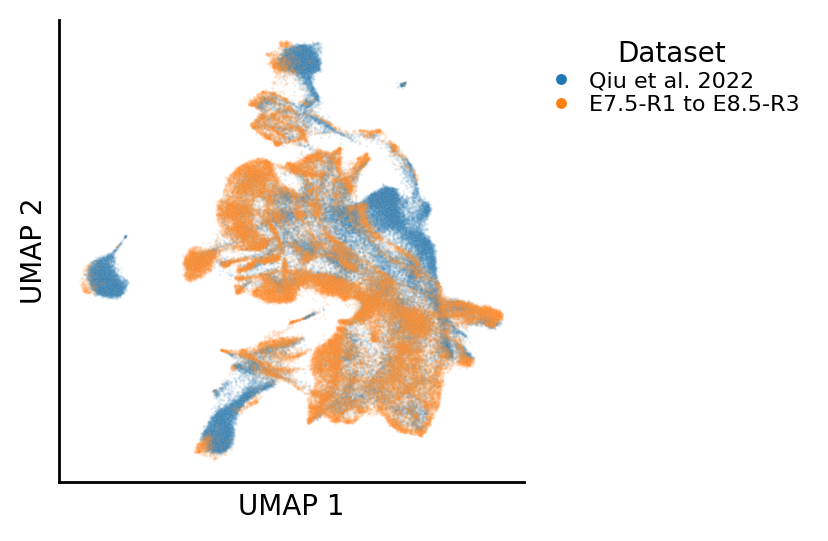

In [32]:
set_theme()

fig = plt.figure(figsize=(3,3), dpi=200)

name_mapping = {
    'qiu2022' :  'Qiu et al. 2022',
    'devmap' : 'E7.5-R1 to E8.5-R3'
}

sns.scatterplot(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    hue=[name_mapping.get(x, x) for x in adata.obs["dataset"]],
    s=1,alpha=0.1,
    palette='tab10')


# set alpha of legend markers to 1
handles, labels = plt.gca().get_legend_handles_labels()
for handle in handles:
    handle.set_alpha(1)
plt.legend(title="Dataset", loc='upper left', bbox_to_anchor=(1, 1),
           markerscale=4, fontsize=8)
plt.xticks([])
plt.yticks([])
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
save_plot("integration/early_integration_umap.svg", fig)